# Fit a DZ spectrum

Fit Ca, Mg and Fe in the included PG 1225-079 UVES spectrum.
Run from this checkout. Parameters follow
[Klein et al. (2011)](https://doi.org/10.1088/0004-637X/741/1/64).
Abundances are `log10 N(Z)/N(He)`.

## Imports

In [1]:
from dataclasses import replace
from datetime import datetime, timezone
from pathlib import Path
import hashlib
import json
import pickle
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

repo = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "src/wd_spectra/__init__.py").is_file()),
    None,
)
if repo is None:
    raise RuntimeError("Run this notebook from the OpenWD source checkout.")
if repo is not None:
    if "wd_spectra" in sys.modules:
        loaded = Path(sys.modules["wd_spectra"].__file__).resolve()
        if repo.resolve() not in loaded.parents:
            raise RuntimeError("Restart the kernel to use this checkout.")
    sys.path.insert(0, str(repo / "src"))

import wd_spectra
from wd_spectra import DZConfig, compute_dz
from wd_spectra.models import AtmosphereConvergenceWarning
from wd_spectra.radiative_transfer import compiled_backend_available

plt.rcParams.update({
    "figure.dpi": 110, "axes.labelsize": 13, "axes.titlesize": 13,
    "xtick.labelsize": 11, "ytick.labelsize": 11,
})
C_KMS = 299_792.458
NOTEBOOK_START = time.perf_counter()
print(f"OpenWD {wd_spectra.__version__}; compiled backend: {compiled_backend_available()}")

OpenWD 0.1.4; compiled backend: True


## Set the parameters

Teff, log g, H/He and the other metals stay fixed.

In [2]:
TARGET = "PG 1225-079"
TEFF = 10_800.0   # K, adopted from Klein et al. (2011), not fitted
LOGG = 8.0        # cgs, adopted from Klein et al. (2011), not fitted
LOG_H_HE = -4.05  # log10 N(H)/N(He), Klein et al. (2011), held fixed

# Klein et al. (2011), Table 5, 10800 K / log g 8.0 column: log10 N(Z)/N(He)
LITERATURE = {"Ca": -8.06, "Mg": -7.27, "Fe": -7.42, "Sc": -11.29, "Ti": -9.45,
              "V": -10.41, "Cr": -9.27, "Mn": -9.79, "Ni": -8.76}
LITERATURE_ERROR = {"Ca": 0.03, "Mg": 0.05, "Fe": 0.07}  # their quoted errors
FIT_ELEMENTS = ("Ca", "Mg", "Fe")  # fitted in this order
LITERATURE_RV_KMS = 49.0  # heliocentric, incl. gravitational redshift (Klein et al. 2011)

QUALITY = "production"  # the tested PG 1225 cold-start setting
DATA_FILE = repo / "examples/data/pg1225-uves.npz"
OUTPUT_ROOT = Path("results") / "dz-fit-pg1225"
USE_CACHED_ATMOSPHERE = True   # reuse this notebook's earlier cold start if it is still valid
RUN_FINAL_COLD_START = False   # optional extra cold start at the fitted composition

start_config = DZConfig(
    effective_temperature=TEFF,
    logg=LOGG,
    abundances=dict(LITERATURE),
    log_hydrogen_abundance=LOG_H_HE,
    quality=QUALITY,
)
print(f"Teff = {TEFF:.0f} K, log g = {LOGG:.1f}, log H/He = {LOG_H_HE:.2f}")

Teff = 10800 K, log g = 8.0, log H/He = -4.05


## Load the observed spectrum

Wavelengths: vacuum, barycentric Angstrom. Errors: approximate pipeline values.
[Data notes](data/README.md).

In [3]:
def load_observation(path):
    info = json.loads(path.with_suffix(".json").read_text())
    if hashlib.sha256(path.read_bytes()).hexdigest() != info["sha256"]:
        raise RuntimeError(f"{path} does not match its recorded checksum")
    if info["wavelength_frame"] != "vacuum, barycentric":
        raise ValueError("Use vacuum, barycentric wavelengths for this example")
    with np.load(path, allow_pickle=False) as data:
        wave, flux, error = (data[name].copy() for name in ("wave", "flux", "error"))
    if wave.ndim != 1 or not (wave.shape == flux.shape == error.shape):
        raise ValueError("Spectrum columns must be matching one-dimensional arrays")
    if not all(np.all(np.isfinite(x)) for x in (wave, flux, error)):
        raise ValueError("Spectrum contains non-finite values")
    if not np.all(np.diff(wave) > 0) or not np.all(error > 0):
        raise ValueError("Wavelengths must increase and errors must be positive")
    return wave, flux, error, info


obs_wave, obs_flux, obs_error, observation = load_observation(DATA_FILE)
RESOLVING_POWER = observation["resolving_power"]
provenance = observation["sources"]
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print(f"{TARGET}: {len(obs_wave)} pixels, {obs_wave[0]:.0f}-{obs_wave[-1]:.0f} Angstrom; "
      f"R = {RESOLVING_POWER:.0f}")


PG 1225-079: 40000 pixels, 3300-4500 Angstrom; R = 19540


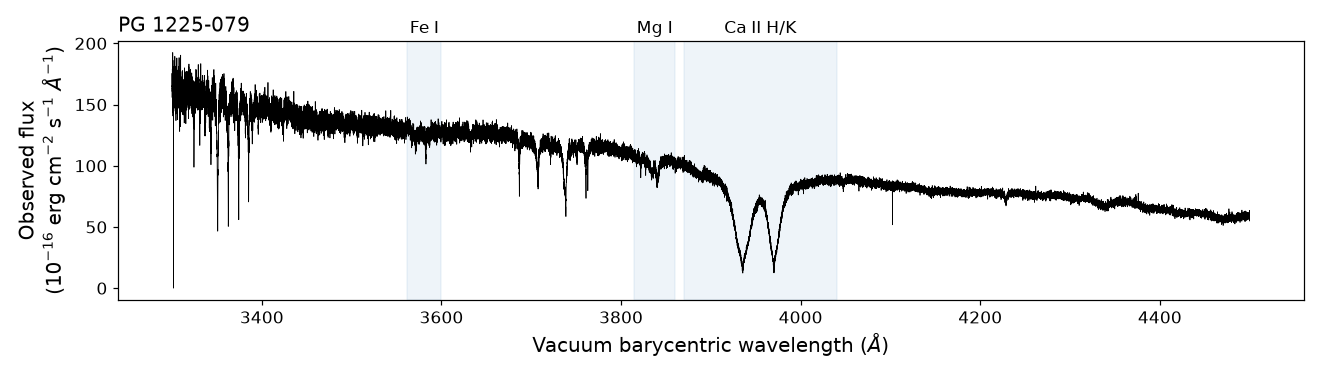

In [ ]:
# Inspect the data before fitting.
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.plot(obs_wave, obs_flux, color="k", lw=0.5)
for label, lower, upper in [("Fe I", 3562, 3600), ("Mg I", 3815, 3860), ("Ca II H/K", 3870, 4040)]:
    ax.axvspan(lower, upper, color="#2878B5", alpha=0.08)
    ax.text((lower + upper) / 2, 1.03, label, transform=ax.get_xaxis_transform(),
            ha="center", fontsize=11, clip_on=False)
ax.set_xlabel(r"Vacuum barycentric wavelength ($\AA$)")
ax.set_ylabel("Observed flux\n" + r"($10^{-16}$ erg cm$^{-2}$ s$^{-1}$ $\AA^{-1}$)")
ax.set_title(TARGET, loc="left")
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "observed-spectrum.png", dpi=250)
fig.savefig(OUTPUT_ROOT / "observed-spectrum.pdf")
plt.show()


## Calculate one atmosphere

The cold start took 27 minutes here. Reuse only your own matching cache.

In [4]:
CACHE = OUTPUT_ROOT / "cold-start.pkl"
probe = np.array([3900.0, 4000.0])
base = None
if USE_CACHED_ATMOSPHERE and CACHE.is_file():
    with open(CACHE, "rb") as stream:
        saved = pickle.load(stream)
    # A fixed synthesis records whether the structure matches this exact request.
    check = compute_dz(start_config, probe, initial_atmosphere=saved["result"].atmosphere,
                       relax_atmosphere=False)
    if check.atmosphere.metadata["fixed_synthesis_request_verified"]:
        base, cold_seconds = saved["result"], saved["seconds"]
        print(f"Loaded cached cold start from {CACHE} "
              f"(originally {cold_seconds / 60:.1f} min)")
    else:
        print("Cached atmosphere does not match this request or code version; recomputing.")
if base is None:
    print(f"Cold start for {TARGET} ({QUALITY}); allow tens of minutes.", flush=True)
    started = time.perf_counter()
    base = compute_dz(start_config, probe)
    cold_seconds = time.perf_counter() - started
    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    with open(CACHE, "wb") as stream:
        pickle.dump({"result": base, "seconds": cold_seconds}, stream)
    print(f"Cold start finished in {cold_seconds / 60:.1f} min; cached at {CACHE}")

Cold start for PG 1225-079 (production); this takes about 15-20 min.


/Users/bijan1339/Projects/OpenWD/.claude/worktrees/happy-cori-e4fbef/src/wd_spectra/metals.py:4136: RuntimeWarning: divide by zero encountered in log
  float(np.max(np.abs(np.log(


/Users/bijan1339/Projects/OpenWD/.claude/worktrees/happy-cori-e4fbef/src/wd_spectra/metals.py:3973: RuntimeWarning: divide by zero encountered in log
  + np.log(upper_partition)
/Users/bijan1339/Projects/OpenWD/.claude/worktrees/happy-cori-e4fbef/src/wd_spectra/metals.py:3974: RuntimeWarning: divide by zero encountered in log
  - np.log(lower_partition)
/Users/bijan1339/Projects/OpenWD/.claude/worktrees/happy-cori-e4fbef/src/wd_spectra/metals.py:3971: RuntimeWarning: invalid value encountered in subtract
  np.log(2.0)
/Users/bijan1339/Projects/OpenWD/.claude/worktrees/happy-cori-e4fbef/src/wd_spectra/metals.py:3670: RuntimeWarning: invalid value encountered in subtract
  weights = np.exp(np.clip(cumulative - maximum, -745.0, 0.0))


Cold start finished in 27.4 min; cached at results/dz-fit-pg1225/cold-start.pkl


## Check convergence

Stop unless all five numerical checks pass.

In [5]:
certificate = base.atmosphere.metadata["equilibrium_certificate"]
for name in certificate["required_checks"]:
    check = certificate["checks"][name]
    print(f"{name:45s} {check['value']:.3g} < {check['tolerance']:.3g}  "
          f"{'pass' if check['passed'] else 'FAIL'}")
print("Certificate verified:", certificate["verified"])
if not certificate["verified"]:
    raise RuntimeError(f"Cold start is not certified: {certificate['failures']}")

all_depth_flux                                1.58e-06 < 0.003  pass
local_energy                                  1.12e-05 < 0.003  pass
temperature_stationarity                      7.86e-05 < 0.0003  pass
source_closure                                1.98e-15 < 1e-06  pass
boundary_screening                            0.000608 < 0.003  pass
Certificate verified: True


## Define the fitting functions

Hold the thermal structure fixed. Recompute populations and opacity for each trial.
Fit a Gaussian instrument profile and a linear continuum.
Mask Ca II cores ([Klein et al. 2011](https://doi.org/10.1088/0004-637X/741/1/64)).

In [6]:
MODEL_STEP_KMS = 2.0
WINDOWS = {
    "Ca": [(3870.0, 4040.0)],                    # Ca II K and H
    "Mg": [(3815.0, 3860.0)],                    # Mg I 3830/3833/3839 triplet
    "Fe": [(3562.0, 3600.0), (3715.0, 3730.0), (3744.0, 3756.0)],  # Fe I 3571, 3582, 3721, 3751
}
CORE_MASKS = [(3934.78, 1.0), (3969.59, 1.0)]    # Ca II K, H: centre, half-width
POLY_DEGREE = 1


def model_grid(lower, upper, pad=5.0):
    # Uniform in ln(wavelength), so a constant-R Gaussian has a fixed width.
    n = int(np.log((upper + pad) / (lower - pad)) * C_KMS / MODEL_STEP_KMS) + 1
    return (lower - pad) * np.exp(np.arange(n) * MODEL_STEP_KMS / C_KMS)


def synthesize(abundances, wave):
    # Emergent spectrum on the fixed cold-start structure (no relaxation).
    config = replace(start_config, abundances=dict(abundances))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", AtmosphereConvergenceWarning)  # expected; see above
        result = compute_dz(config, wave, initial_atmosphere=base.atmosphere,
                            relax_atmosphere=False)
    return result.spectrum.surface_flux_lambda


def observe(wave_rest, flux, rv_kms, wave_obs):
    # Instrumental broadening, Doppler shift, then resampling onto the data.
    sigma = C_KMS / RESOLVING_POWER / (2 * np.sqrt(2 * np.log(2))) / MODEL_STEP_KMS
    smooth = gaussian_filter1d(flux, sigma, mode="nearest")
    return np.interp(wave_obs, wave_rest * (1 + rv_kms / C_KMS), smooth)


def pseudo_continuum_fit(data, error, model, x):
    # Best (data ~ polynomial(x) * model); returns chi2 and the scaled model.
    design = model[:, None] * x[:, None] ** np.arange(POLY_DEGREE + 1)
    coefficients = np.linalg.lstsq(design / error[:, None], data / error, rcond=None)[0]
    fitted = design @ coefficients
    return float(np.sum(((data - fitted) / error) ** 2)), fitted


def window_data(lower, upper, rv_kms):
    rest = obs_wave / (1 + rv_kms / C_KMS)
    keep = (rest >= lower) & (rest <= upper)
    for centre, half_width in CORE_MASKS:
        keep &= np.abs(rest - centre) > half_width
    if np.count_nonzero(keep) <= POLY_DEGREE + 1:
        raise ValueError(f"Insufficient unmasked pixels in {lower}-{upper} Angstrom")
    x = (obs_wave[keep] - obs_wave[keep].mean()) / np.ptp(obs_wave[keep])
    return obs_wave[keep], obs_flux[keep], obs_error[keep], x


def element_spectra(element, abundances):
    # One synthesis call per trial covering all windows of this element.
    grids = [model_grid(lo, hi) for lo, hi in WINDOWS[element]]
    flux = synthesize(abundances, np.concatenate(grids))
    split = np.cumsum([len(g) for g in grids])[:-1]
    return list(zip(grids, np.split(flux, split)))


def element_chi2(element, abundances, rv_kms, spectra=None):
    spectra = element_spectra(element, abundances) if spectra is None else spectra
    total, points = 0.0, 0
    for (lower, upper), (wave_rest, flux) in zip(WINDOWS[element], spectra):
        wave, data, error, x = window_data(lower, upper, rv_kms)
        chi2, _ = pseudo_continuum_fit(data, error, observe(wave_rest, flux, rv_kms, wave), x)
        total, points = total + chi2, points + len(data)
    return total, points


with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    started = time.perf_counter()
    compute_dz(replace(start_config, abundances={**LITERATURE, "Ca": LITERATURE["Ca"] + 0.1}),
               model_grid(*WINDOWS["Mg"][0]), initial_atmosphere=base.atmosphere,
               relax_atmosphere=False)
    trial_seconds = time.perf_counter() - started
print(f"One fixed-structure trial: {trial_seconds:.1f} s")
print("OpenWD's (expected) warning for a changed composition on a fixed structure:")
print(" ", next(str(w.message) for w in caught
                if issubclass(w.category, AtmosphereConvergenceWarning))[:240], "...")

One fixed-structure trial: 15.7 s
OpenWD's (expected) warning for a changed composition on a fixed structure:
  Returning a DZ spectrum from an atmosphere that does not verify equilibrium for the requested parameters and physics (checkpoint request mismatch) (maximum all-depth flux residual=1.581e-06, maximum log-temperature correction=7.861e-05, non ...


## Fit a velocity shift for each element

These are nuisance shifts, not a systemic velocity measurement.

In [7]:
start_spectra = {element: element_spectra(element, LITERATURE) for element in FIT_ELEMENTS}
velocities = np.arange(20.0, 90.1, 1.0)
RV_KMS, RV_SCANS = {}, {}
for element in FIT_ELEMENTS:
    chi2 = np.array([element_chi2(element, LITERATURE, v, start_spectra[element])[0]
                     for v in velocities])
    RV_SCANS[element] = chi2
    index = int(np.argmin(chi2))
    if index in (0, len(velocities) - 1):
        raise RuntimeError(f"{element}: velocity minimum is at the scan boundary")
    i = int(np.clip(index, 2, len(velocities) - 3))
    a, b, _ = np.polyfit(velocities[i - 2:i + 3], chi2[i - 2:i + 3], 2)
    if not np.isfinite(a) or a <= 0:
        raise RuntimeError(f"{element}: velocity curve has no convex minimum")
    RV_KMS[element] = float(-b / (2 * a))
    if not velocities[i - 2] <= RV_KMS[element] <= velocities[i + 2]:
        raise RuntimeError(f"{element}: velocity minimum lies outside its local scan")
    print(f"{element}: {RV_KMS[element]:.1f} km/s")
print(f"Klein et al. (2011), all species: {LITERATURE_RV_KMS:.0f} ± 3 km/s")

Ca: 62.6 km/s
Mg: 51.2 km/s
Fe: 42.7 km/s
Klein et al. (2011), all species: 49 ± 3 km/s


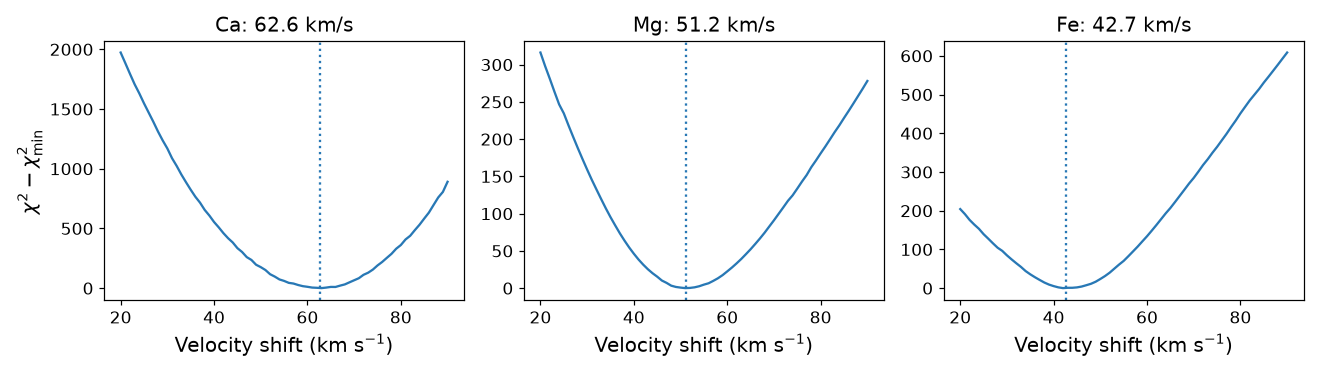

In [ ]:
fig, axes = plt.subplots(1, len(FIT_ELEMENTS), figsize=(12, 3.4))
for ax, element in zip(axes, FIT_ELEMENTS):
    chi2 = RV_SCANS[element]
    ax.plot(velocities, chi2 - chi2.min(), color="#2878B5")
    ax.axvline(RV_KMS[element], color="#2878B5", ls=":")
    ax.set_xlabel(r"Velocity shift (km s$^{-1}$)")
    ax.set_title(f"{element}: {RV_KMS[element]:.1f} km/s")
axes[0].set_ylabel(r"$\chi^2 - \chi^2_{\min}$")
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "velocity-scans.png", dpi=250)
fig.savefig(OUTPUT_ROOT / "velocity-scans.pdf")
plt.show()


## Fit Ca, Mg and Fe

Scan one abundance at a time. Printed widths omit noise covariance and model uncertainty.

In [8]:
OFFSETS = np.round(np.arange(-0.4, 0.41, 0.1), 2)
fitted = dict(LITERATURE)
results = {}
for element in FIT_ELEMENTS:
    started = time.perf_counter()
    values = fitted[element] + OFFSETS
    scans = [element_chi2(element, {**fitted, element: v}, RV_KMS[element]) for v in values]
    chi2 = np.array([s[0] for s in scans])
    points = scans[0][1]
    i = int(np.argmin(chi2))
    if i in (0, len(values) - 1):
        warnings.warn(f"{element}: chi2 minimum at the scan edge; widen OFFSETS", RuntimeWarning)
        raise RuntimeError(f"{element}: cannot report an abundance at the scan boundary")
    lo, hi = max(i - 2, 0), min(i + 3, len(values))
    a, b, c = np.polyfit(values[lo:hi], chi2[lo:hi], 2)
    if not np.isfinite(a) or a <= 0:
        raise RuntimeError(f"{element}: local chi-square curve has no convex minimum")
    best = -b / (2 * a)
    if not values[lo] <= best <= values[hi - 1]:
        raise RuntimeError(f"{element}: quadratic minimum lies outside the local scan")
    chi2_min = c - b**2 / (4 * a)
    reduced = chi2_min / (points - (POLY_DEGREE + 1) * len(WINDOWS[element]) - 1)
    error = np.sqrt(1 / a) * np.sqrt(max(reduced, 1.0))
    fitted[element] = float(best)
    results[element] = dict(values=values, chi2=chi2, best=float(best), error=float(error),
                            reduced_chi2=float(reduced), points=points)
    print(f"{element}: log {element}/He = {best:.2f} ± {error:.3f} (formal)  "
          f"reduced chi2 = {reduced:.2f} over {points} pixels  "
          f"[{time.perf_counter() - started:.0f} s]")

Ca: log Ca/He = -7.79 ± 0.002 (formal)  reduced chi2 = 0.62 over 5534 pixels  [354 s]


Mg: log Mg/He = -7.30 ± 0.011 (formal)  reduced chi2 = 0.54 over 1500 pixels  [135 s]


Fe: log Fe/He = -7.48 ± 0.017 (formal)  reduced chi2 = 0.37 over 2168 pixels  [202 s]


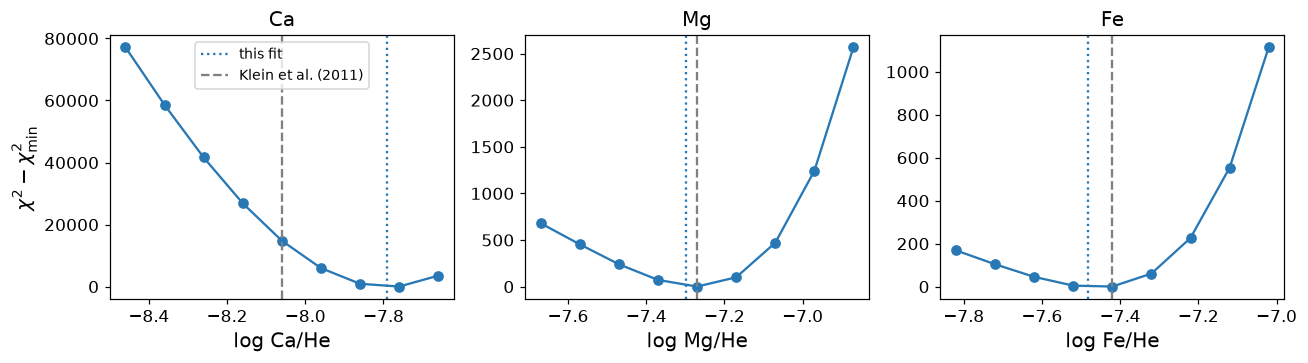

In [9]:
fig, axes = plt.subplots(1, len(FIT_ELEMENTS), figsize=(12, 3.4))
for ax, element in zip(axes, FIT_ELEMENTS):
    r = results[element]
    ax.plot(r["values"], r["chi2"] - r["chi2"].min(), "o-", color="#2878B5")
    ax.axvline(r["best"], color="#2878B5", ls=":", label="this fit")
    ax.axvline(LITERATURE[element], color="0.5", ls="--", label="Klein et al. (2011)")
    ax.set_xlabel(f"log {element}/He")
    ax.set_title(element)
axes[0].set_ylabel(r"$\chi^2 - \chi^2_{\min}$")
axes[0].legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "abundance-scans.png", dpi=250)
fig.savefig(OUTPUT_ROOT / "abundance-scans.pdf")
plt.show()

## Optional: check a new atmosphere

Set `RUN_FINAL_COLD_START = True` to solve at the fitted mixture.
Then rerun the fit and plots, without rerunning either cold-start cell.

In [10]:
final = None
if RUN_FINAL_COLD_START:
    final_config = replace(start_config, abundances=dict(fitted))
    started = time.perf_counter()
    final = compute_dz(final_config, probe)
    final_certificate = final.atmosphere.metadata["equilibrium_certificate"]
    print(f"Final cold start: {(time.perf_counter() - started) / 60:.1f} min, "
          f"certificate verified: {final_certificate['verified']}")
    if not final_certificate["verified"]:
        raise RuntimeError(f"Fitted-composition cold start failed: {final_certificate['failures']}")
    base = final  # later cells synthesize on the fitted-composition structure
    with open(OUTPUT_ROOT / "final-cold-start.pkl", "wb") as stream:
        pickle.dump({"result": final, "seconds": time.perf_counter() - started}, stream)
    for element in FIT_ELEMENTS:
        print(f"{element}: chi2 at the fitted abundances = "
              f"{element_chi2(element, fitted, RV_KMS[element])[0]:.0f} on the new structure, "
              f"{results[element]['chi2'].min():.0f} on the starting structure")
else:
    print("Skipped: the spectra below use the structure relaxed at the starting composition.")

Skipped: the spectra below use the structure relaxed at the starting composition.


## Plot the fit

Black: data. Blue: fitted mixture. Dashed: starting mixture.
Shading marks excluded cores.

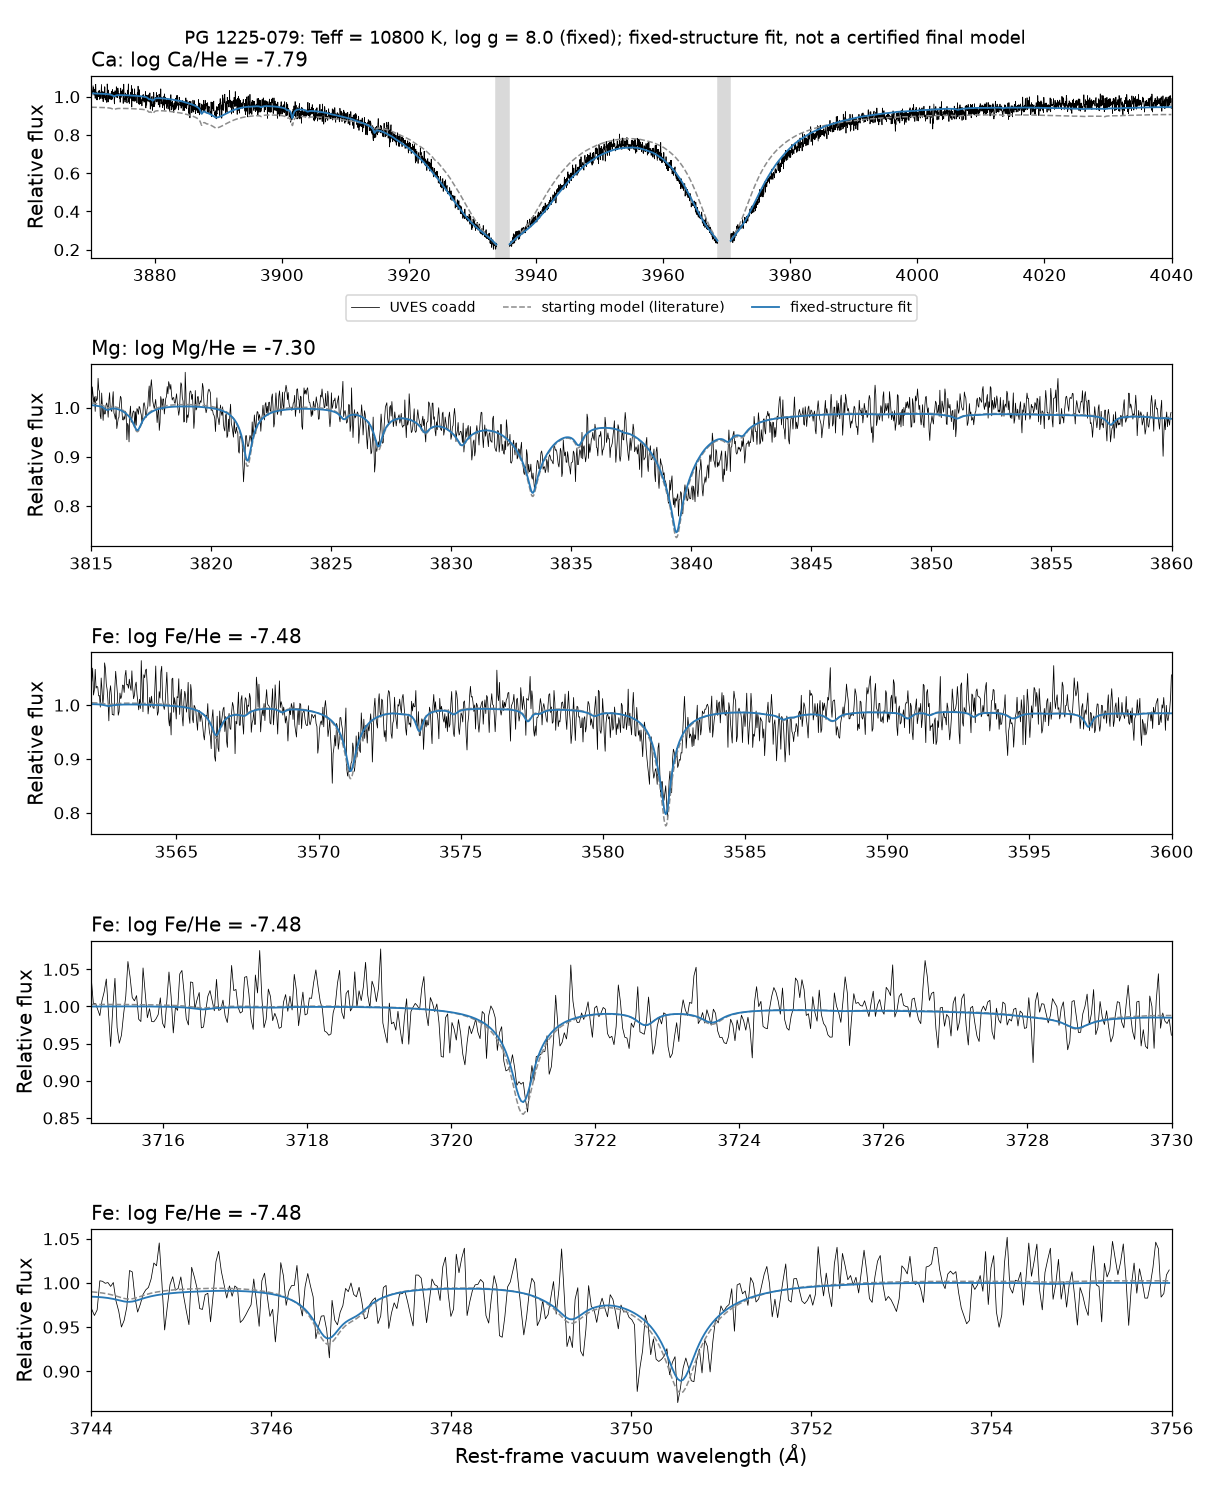

In [11]:
panels = [(e, window) for e in FIT_ELEMENTS for window in WINDOWS[e]]
best_spectra = {e: element_spectra(e, fitted) for e in FIT_ELEMENTS}
fig, axes = plt.subplots(len(panels), 1, figsize=(11, 2.7 * len(panels)))
for ax, (element, (lower, upper)) in zip(axes, panels):
    k = WINDOWS[element].index((lower, upper))
    rv = RV_KMS[element]
    wave, data, error, x = window_data(lower, upper, rv)
    rest = wave / (1 + rv / C_KMS)
    best_model = observe(*best_spectra[element][k], rv, wave)
    start_model = observe(*start_spectra[element][k], rv, wave)
    _, scaled_best = pseudo_continuum_fit(data, error, best_model, x)
    _, scaled_start = pseudo_continuum_fit(data, error, start_model, x)
    norm = np.percentile(best_model, 95)
    continuum = scaled_best / best_model
    # Break plotted lines across excluded cores instead of bridging missing pixels.
    gaps = np.r_[False, np.diff(rest) > 1.5 * np.median(np.diff(rest))]
    displayed = [data / continuum / norm, scaled_start / continuum / norm, best_model / norm]
    for values in displayed:
        values[gaps] = np.nan
    ax.plot(rest, displayed[0], color="k", lw=0.5, label="UVES coadd")
    ax.plot(rest, displayed[1], color="0.55", lw=1, ls="--",
            label="starting model (literature)")
    ax.plot(rest, displayed[2], color="#2878B5", lw=1.2,
            label=("fixed-structure fit" if final is None else "fitted composition on re-solved structure"))
    for centre, half_width in CORE_MASKS:
        if lower < centre < upper:
            ax.axvspan(centre - half_width, centre + half_width, color="0.85")
    ax.set_xlim(lower, upper)
    ax.set_ylabel("Relative flux")
    ax.set_title(f"{element}: log {element}/He = {fitted[element]:.2f}", loc="left")
axes[-1].set_xlabel(r"Rest-frame vacuum wavelength ($\AA$)")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), fontsize=9, ncol=3)
status = ("re-solved structure; abundance self-consistency not established" if final is not None
          else "fixed-structure fit, not a certified final model")
fig.suptitle(f"{TARGET}: Teff = {TEFF:.0f} K, log g = {LOGG:.1f} (fixed); {status}", fontsize=12)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "pg1225_fit.png", dpi=250, bbox_inches="tight")
fig.savefig(OUTPUT_ROOT / "pg1225_fit.pdf", bbox_inches="tight")
plt.show()

## Compare with the literature

In [12]:
print(f"{'element':8s} {'Klein+2011':>12s} {'this fit (formal)':>17s} {'difference':>11s} "
      f"{'red. chi2':>10s} {'RV (km/s)':>10s}")
for element in FIT_ELEMENTS:
    r = results[element]
    print(f"{element:8s} {LITERATURE[element]:7.2f} ± {LITERATURE_ERROR[element]:.2f} "
          f"{r['best']:9.2f} ± {r['error']:.3f} {r['best'] - LITERATURE[element]:+11.2f} "
          f"{r['reduced_chi2']:10.2f} {RV_KMS[element]:10.1f}")
print(f"Cold start: {cold_seconds / 60:.1f} min;  "
      f"notebook wall time: {(time.perf_counter() - NOTEBOOK_START) / 60:.1f} min")
summary = {
    "target": TARGET, "teff_fixed": TEFF, "logg_fixed": LOGG, "log_h_he_fixed": LOG_H_HE,
    "quality": QUALITY, "radial_velocity_kms": RV_KMS,
    "starting_abundances": LITERATURE, "fitted_abundances": fitted,
    "fit": {e: {k: results[e][k] for k in ("best", "error", "reduced_chi2", "points")}
            for e in FIT_ELEMENTS},
    "uncertainties": "uncalibrated diagonal-noise curvature widths; resampling covariance, nuisance-parameter uncertainty and model systematics excluded",
    "structure": ("re-solved at the previous fitted composition; refit requires a new certificate"
                  if final is not None else "relaxed at the starting composition; final cold start not run"),
    "cold_start_certificate_verified": certificate["verified"],
    "cold_start_seconds": cold_seconds,
    "compiled_backend": compiled_backend_available(),
    "model_request_fingerprint": base.atmosphere.metadata["model_request_fingerprint"],
    "observations": provenance,
    "fit_windows_vacuum_angstrom": WINDOWS,
    "masked_cores_vacuum_angstrom": CORE_MASKS,
    "continuum_degree": POLY_DEGREE, "resolving_power": RESOLVING_POWER,
    "model_step_kms": MODEL_STEP_KMS,
    "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
}
(OUTPUT_ROOT / "fit-summary.json").write_text(json.dumps(summary, indent=2))
print(f"Saved {OUTPUT_ROOT / 'fit-summary.json'}")

element    Klein+2011  this fit (formal)  difference  red. chi2  RV (km/s)
Ca         -8.06 ± 0.03     -7.79 ± 0.002       +0.27       0.62       62.6
Mg         -7.27 ± 0.05     -7.30 ± 0.011       -0.03       0.54       51.2
Fe         -7.42 ± 0.07     -7.48 ± 0.017       -0.06       0.37       42.7
Cold start: 27.4 min;  notebook wall time: 44.4 min
Saved results/dz-fit-pg1225/fit-summary.json


## Use your own spectrum

Replace the data cell. Set the resolution, starting parameters and windows.
Use vacuum wavelengths and positive errors.
A cold start and refit must check abundance self-consistency.
[Fitting notes](../docs/examples/fitting-dz.md).